In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [35]:
df.shape

(150, 6)

In [36]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [37]:
df.duplicated().sum()

0

In [38]:
df.drop(columns='Id',axis=1,inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [39]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

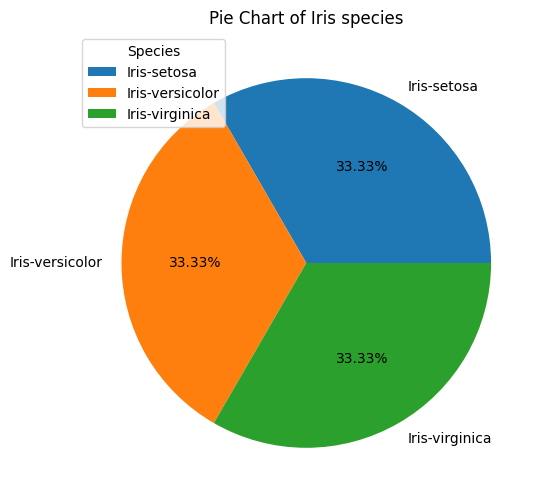

In [40]:

plt.figure(figsize=(6, 6))
plt.pie(df['Species'].value_counts(), labels=df['Species'].value_counts().index, autopct='%.2f%%')
plt.title('Pie Chart of Iris species')

plt.legend(labels=df['Species'].value_counts().index, title="Species", loc="upper left")
plt.show()

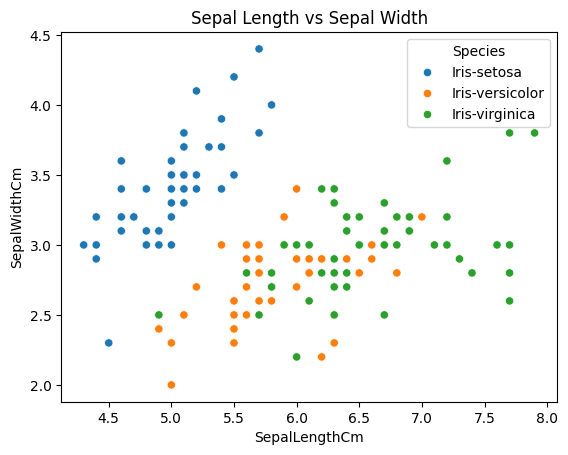

In [41]:
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', data=df, hue='Species')
plt.title('Sepal Length vs Sepal Width')
plt.show()

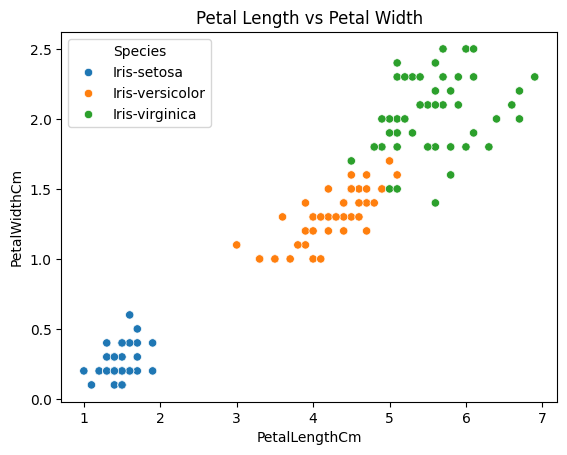

In [42]:
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', data=df, hue='Species')
plt.title('Petal Length vs Petal Width')
plt.show()

<Axes: >

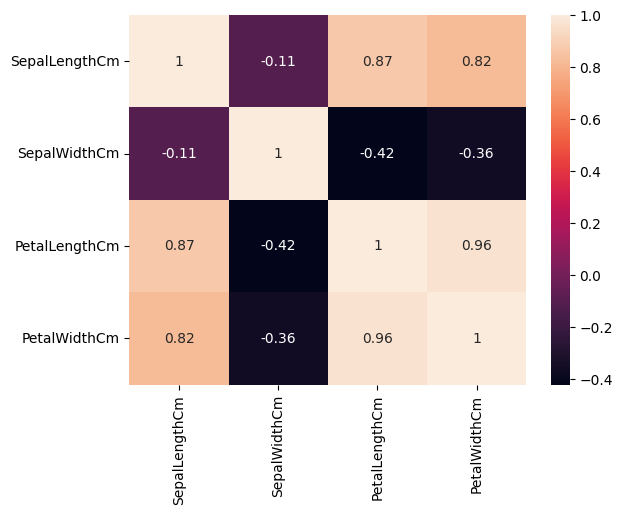

In [43]:
n_df = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
sns.heatmap(n_df.corr(), annot=True)

In [44]:
x = df.drop(['Species'], axis=1)
y = df['Species']

#  Working Algorithm of K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a **supervised learning algorithm** used for both **classification** and **regression**.  
It is a **lazy learning algorithm**, meaning it does not build an explicit model during training.

---

#  Core Idea

KNN works on a simple principle:

> “Similar data points exist close to each other.”

It classifies or predicts a value based on the **K closest data points** in the training dataset.

---

# KNN Example: Age and Salary

## Dataset

| Person | Age | Salary | Class     |
| ------ | --- | ------ | --------- |
| A      | 25  | 50k    | Low Risk  |
| B      | 30  | 55k    | High Risk |
| C      | 45  | 80k    | High Risk |
| D      | 28  | 52k    | Low Risk  |


**New person:** E = (27, 51k)

The goal is to predict the class of person E using K-Nearest Neighbors (KNN).

---

## 1️⃣ Measure “Similarity” Using Distance

KNN calculates the distance between the new point (E) and all training points to find which points are **most similar**.  

**Distance metric:** Euclidean distance

$$
d = \sqrt{(Age_1 - Age_2)^2 + (Salary_1 - Salary_2)^2}
$$

> Note: Salaries are converted from "k" to actual values in dollars (50k → 50000).

### Step-by-step distance calculations:

1. **Distance E → A**  

$$
d = \sqrt{(27-25)^2 + (51000-50000)^2} 
= \sqrt{2^2 + 1000^2} 
= \sqrt{4 + 1000000} 
= \sqrt{1000004} 
\approx 1000.002
$$

2. **Distance E → B**  

$$
d = \sqrt{(27-30)^2 + (51000-55000)^2} 
= \sqrt{(-3)^2 + (-4000)^2} 
= \sqrt{9 + 16000000} 
= \sqrt{16000009} 
\approx 4000.001
$$

3. **Distance E → C**  

$$
d = \sqrt{(27-45)^2 + (51000-80000)^2} 
= \sqrt{(-18)^2 + (-29000)^2} 
= \sqrt{324 + 841000000} 
= \sqrt{841000324} 
\approx 29000.006
$$

4. **Distance E → D**  

$$
d = \sqrt{(27-28)^2 + (51000-52000)^2} 
= \sqrt{(-1)^2 + (-1000)^2} 
= \sqrt{1 + 1000000} 
= \sqrt{1000001} 
\approx 1000.0005
$$

### Distances Summary:

| Neighbor | Distance to E |
|----------|---------------|
| A        | 1000.002      |
| B        | 4000.001      |
| C        | 29000.006     |
| D        | 1000.0005     |

> **Observation:** Smaller distance → more similar.  
> So, the closest points to E are **D, A, B**.

---

## 2️⃣ Select K Nearest Neighbors

Suppose **K = 3**. We select the 3 neighbors with **smallest distances**:

**K nearest neighbors:** D, A, B

| Neighbor | Distance |
|----------|---------|
| D        | 1000.0005 |
| A        | 1000.002  |
| B        | 4000.001  |

---

## 3️⃣ Classify by Majority Vote

Look at the classes of these 3 neighbors:

| Neighbor | Class      |
|----------|-----------|
| D        | Low Risk  |
| A        | Low Risk  |
| B        | High Risk |

- **Majority class** = Low Risk  
- Therefore, **new person E = (27, 51k) is classified as Low Risk**.

---



#  Step-by-Step Working of KNN Algorithm

##  Step 1: Choose the Value of K

- Select the number of neighbors (**K**).
- Small K → More sensitive to noise.
- Large K → Smoother decision boundary.

---

##  Step 2: Calculate Distance

For a new data point:
- Compute the distance between the new point and all training data points.

### Common Distance Metrics:

1. **Euclidean Distance** (most common)

$$
d = \sqrt{\sum (x_i - y_i)^2}
$$

2. **Manhattan Distance**

$$
d = \sum |x_i - y_i|
$$

3. **Hamming Distance** (for categorical data)

---

##  Step 3: Find K Nearest Neighbors

- Sort all distances in ascending order.
- Select the top K closest data points.

---

##  Step 4: Make Prediction

###  For Classification:
- Perform **majority voting**.
- The class with the highest frequency among K neighbors is chosen.

#  What Type of Data is Suitable for KNN?

**K-Nearest Neighbors (KNN)** is best suited for certain kinds of data because it is **distance-based**.

---

##  1. Numerical (Continuous) Data

KNN works best with **numerical features** because it calculates distance between data points.

**Examples:**
- Height, Weight  
- Age  
- Income  
- Temperature  
- Pixel values in images  

✔ Works very well when features are numeric and properly scaled.

---

##  2. Low to Medium Dimensional Data

KNN performs well when:
- The number of features is small to moderate  

❌ In very high dimensions, KNN suffers from the **Curse of Dimensionality**, where distances become less meaningful.

---

##  3. Well-Scaled Data

Since KNN depends on distance:

Features must be **normalized or standardized**.

Otherwise, large-scale features dominate.

**Example:**
- Salary (0–100000)  
- Age (0–100)  

Without scaling → Salary dominates distance.

---

##  4. Categorical Data

KNN is **not naturally suited** for pure categorical data.

However:
- You can use encoding techniques (e.g., One-Hot Encoding)
- Distance metrics like **Hamming distance** can be used  

But tree-based models often perform better for categorical-heavy datasets.

---

#  Common Applications of KNN

##  Image Recognition

- Handwritten digit recognition  
- Face recognition  

**Example:**  
Recognizing digits in the MNIST dataset  

**Why KNN works?**  
Similar images have similar pixel values.

---

##  Recommendation Systems

- Product recommendation  
- Movie recommendation  

**Example:**  
Recommending movies similar to ones a user liked  

**Idea:**  
Find users with similar preferences and recommend what they liked.

---

##  Medical Diagnosis

- Disease classification  
- Tumor detection (benign vs malignant)  

**Why?**  
Patients with similar symptoms often have similar diagnoses.

---

##  Pattern Recognition

- Speech recognition  
- Gesture recognition  
- Text classification (small datasets)

---

##  Anomaly Detection

- Fraud detection  
- Network intrusion detection  

**Idea:**  
If a data point is far from neighbors → it might be an anomaly.

---

##  Credit Risk Assessment

Classifying whether a loan applicant is high-risk or low-risk.

---

#  When NOT to Use KNN

Avoid KNN when:

- Dataset is very large (millions of rows)
- High dimensional data (hundreds/thousands of features)
- Many irrelevant features
- Real-time prediction with strict latency requirements

In [49]:
from sklearn.datasets import load_iris

iris = load_iris()

In [45]:
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [46]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [52]:
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=25)

# Train on training data
knn.fit(x_train, y_train)

# Predict on test data
y_pred = knn.predict(x_test)

# Evaluate performance
report = classification_report(y_test, y_pred, target_names=iris.target_names)
print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       0.92      0.85      0.88        13
   virginica       0.71      0.83      0.77         6

    accuracy                           0.90        30
   macro avg       0.88      0.89      0.88        30
weighted avg       0.91      0.90      0.90        30



<Axes: >

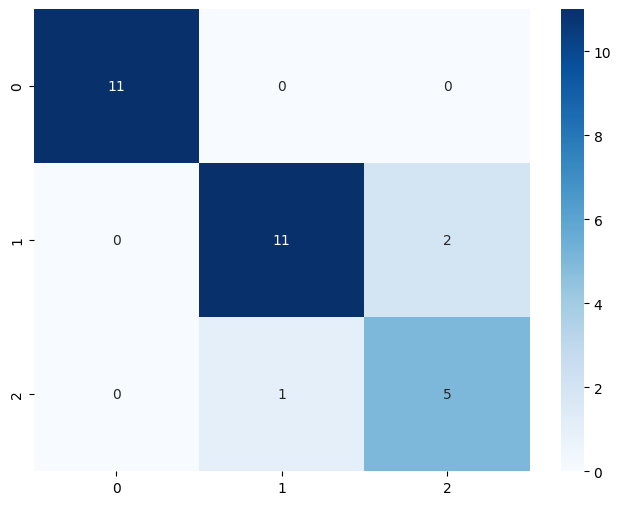

In [54]:
from sklearn.metrics import confusion_matrix

cm_model = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm_model, annot = True, cmap = 'Blues')

In [56]:

new_samples = [
    [5.1, 3.5, 1.4, 0.2],  
    [6.5, 3.0, 5.5, 2.1],  
    [5.9, 3.0, 4.2, 1.5]   
]

# Scale the new samples using the same scaler
new_samples_scaled = scaler.transform(new_samples)

# Predict class labels
predictions = knn.predict(new_samples_scaled)

print(predictions)

['Iris-setosa' 'Iris-virginica' 'Iris-versicolor']


C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
